In [ ]:
# !clone ult to repo

In [60]:
from satelliteSegmentation.datasets.image_dataset import load_data, SatelliteData
import torch
from matplotlib import pyplot as plt
import numpy as np

In [10]:
data = load_data("test", "../data")

100%|██████████| 648/648 [00:00<00:00, 770.51it/s]


Dataset cargado:
X shape = torch.Size([648, 3, 120, 120])
Y shape = torch.Size([648, 3, 120, 120])


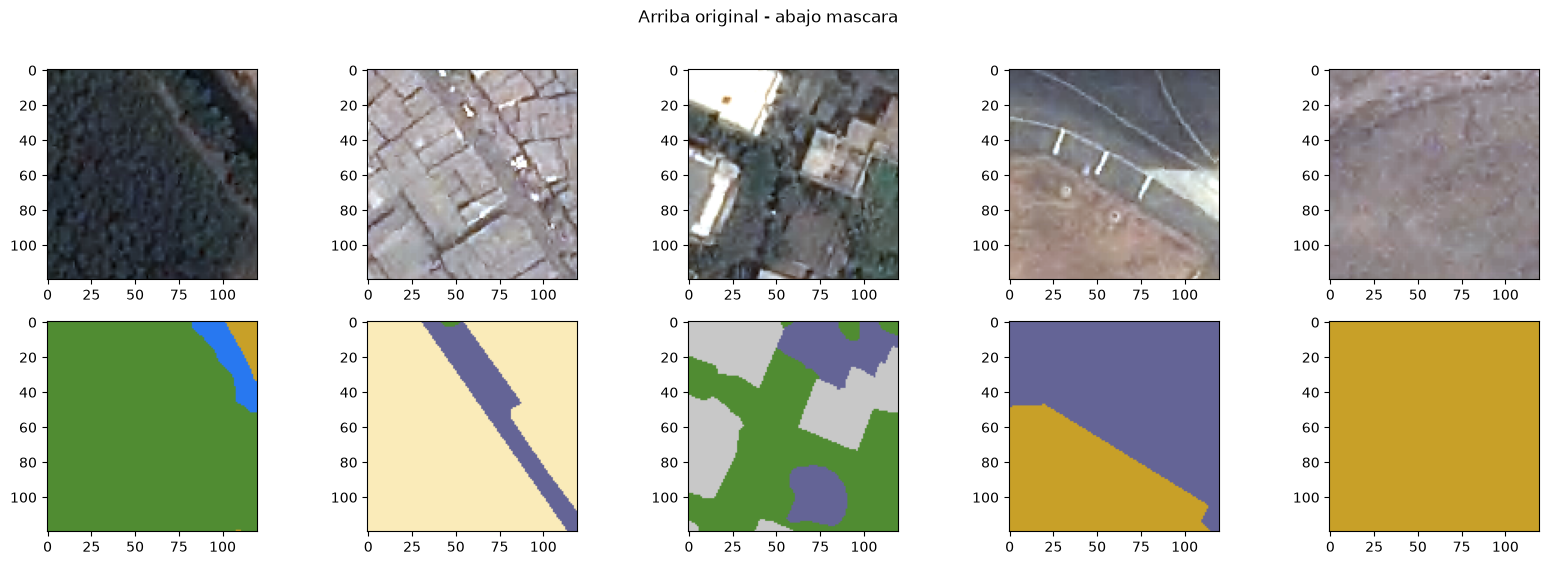

In [ ]:
def show_img_mask(data: SatelliteData, n: int = 3):
    fig, ax = plt.subplots(2, n, figsize=(4 * n, 6))
    for i in range(n):
        x, y = data[np.random.randint(0, len(data))]
        ax[0, i].imshow(x.permute(1, 2, 0) / 255)
        ax[1, i].imshow(y.permute(1, 2, 0) / 255)
    fig.suptitle("Arriba original - abajo mascara")
    return fig, ax


show_img_mask(data, 5)

In [ ]:
LABEL2COLOR = {
    "Informal Settlements": [250, 235, 185],
    "Built-Up": [200, 200, 200],
    "Impervious Surfaces": [100, 100, 150],
    "Vegetation": [80, 140, 50],
    "Barren": [200, 160, 40],
    "Water": [40, 120, 240],
    "Unlabelled": [0, 0, 0],
}
COLOR2LABEL = {tuple(v):k for k, v in LABEL2COLOR.items()}

def calc_imbalance(data: SatelliteData):

    masks_hwc = data.Y.permute(0, 2, 3, 1)
    colors = torch.unique(masks_hwc.reshape(-1, 3), dim=0)
    print("Colores:")
    print(colors)

    total = data.Y.shape[0] * data.Y.shape[2] * data.Y.shape[3]
    label = {}
    for col in colors:
        n_pixels = (masks_hwc == col).all(dim=-1).sum()
        percent = n_pixels / total

        print(f"{COLOR2LABEL[tuple(col.tolist())]:<20}", f"{100 * percent:.2f}")
        label[COLOR2LABEL[tuple(col.tolist())]] = 100 * percent
    return label

imbalance = calc_imbalance(data)


Colores:
tensor([[  0.,   0.,   0.],
        [ 40., 120., 240.],
        [ 80., 140.,  50.],
        [100., 100., 150.],
        [200., 160.,  40.],
        [200., 200., 200.],
        [250., 235., 185.]])
Unlabelled           0.00
Water                2.13
Vegetation           27.41
Impervious Surfaces  23.15
Barren               23.87
Built-Up             10.81
Informal Settlements 12.63
